In [1]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
import geopandas as gpd
from pyproj import Transformer
from project.data_handling import * 
from shop.plotting.plotting_fxns import *
import pandas as pd
import rioxarray

translate_names = {}
for glacier, vals in translate_rgi.items():
    translate_names[vals['6']] = glacier

In [2]:
output_fp = '/ocean/projects/ees260009p/cwilson4/Output/extremes/base_0/'
ds_all = xr.open_zarr(output_fp + 'output.zarr')
ds_all['time'] = ds_all.time - pd.Timedelta(hours=8)

with open(output_fp + 'config.yaml') as f:
    configs = yaml.safe_load(f) 

sites = configs['sites']
rgiids = configs['rgi_ids']

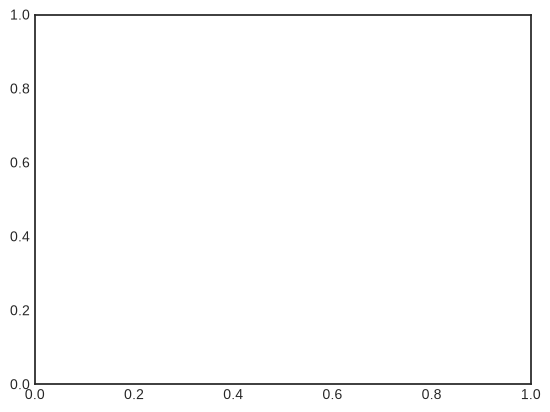

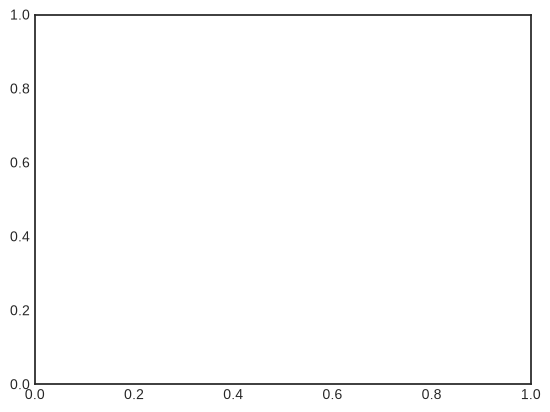

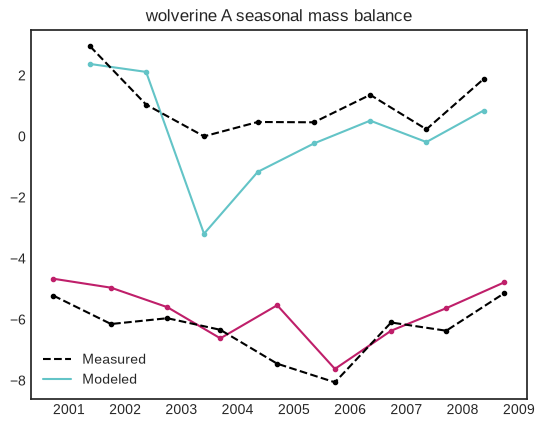

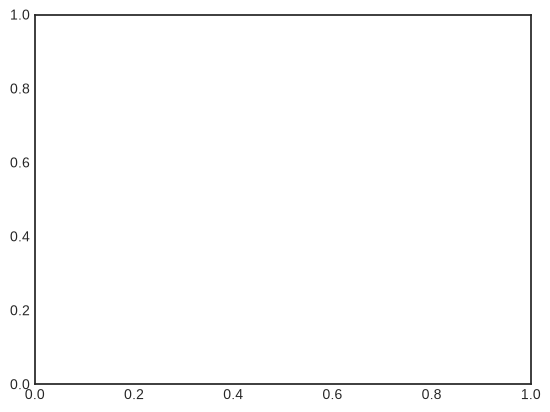

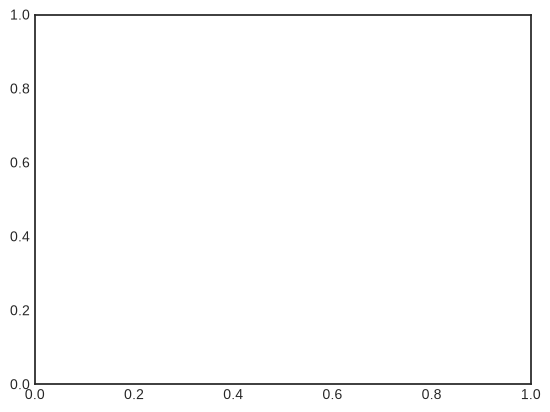

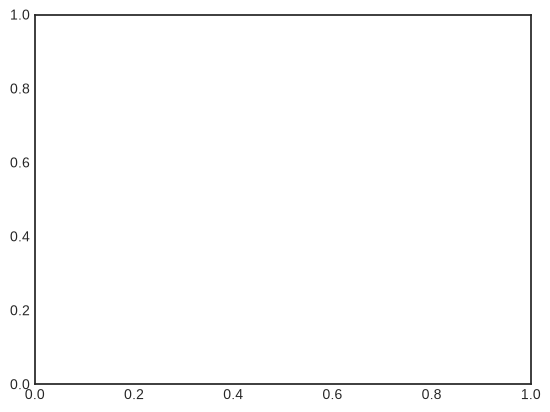

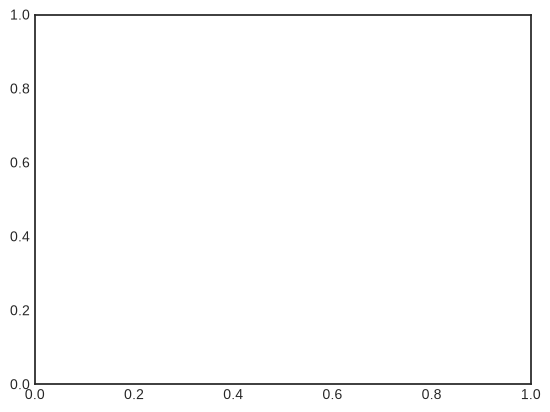

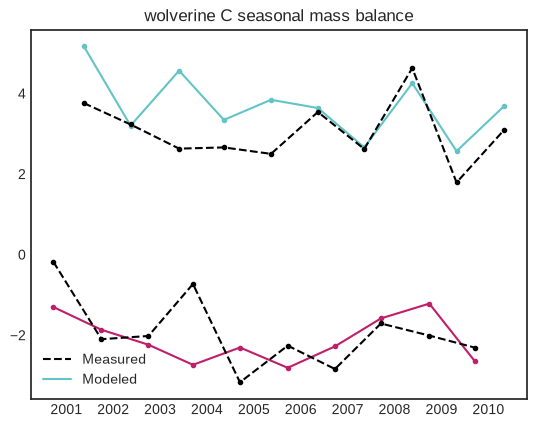

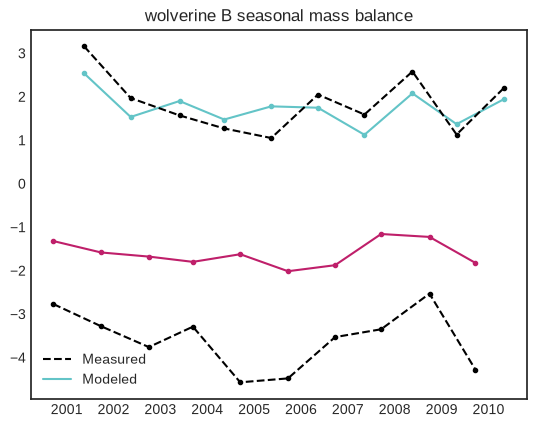

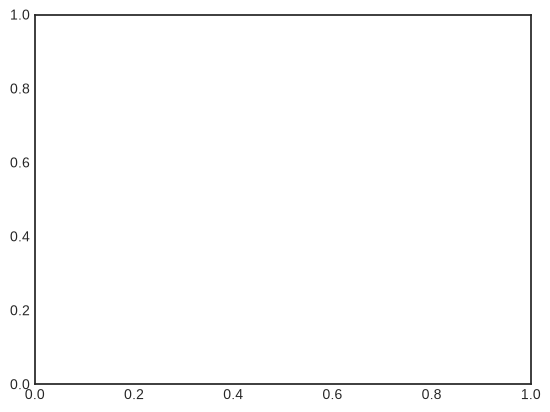

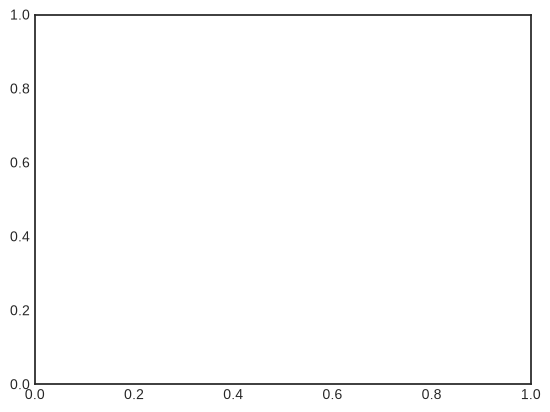

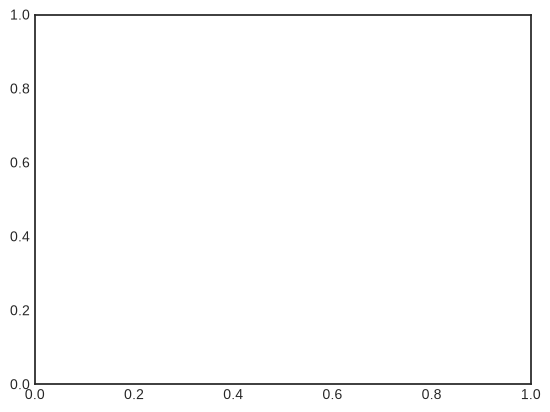

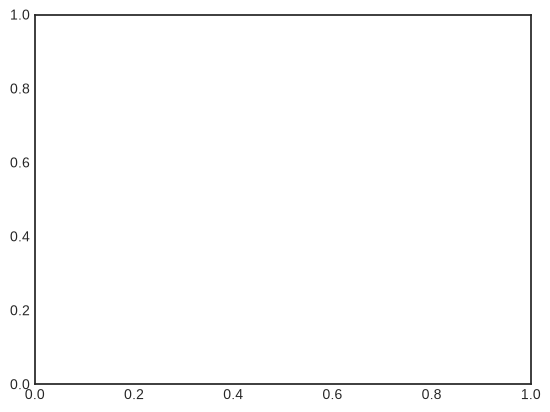

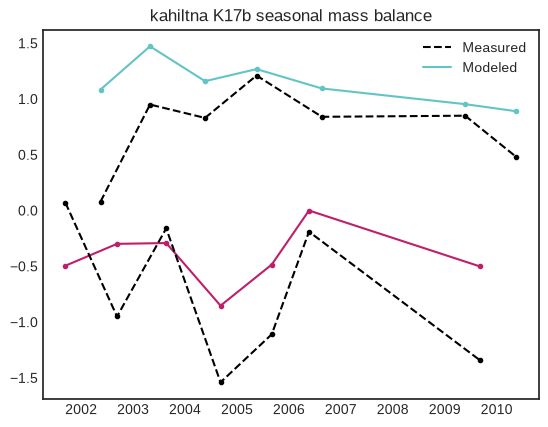

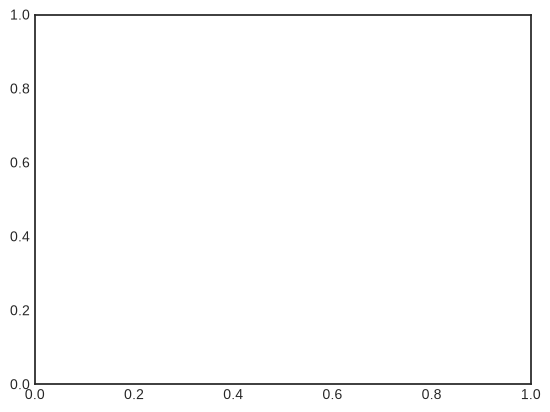

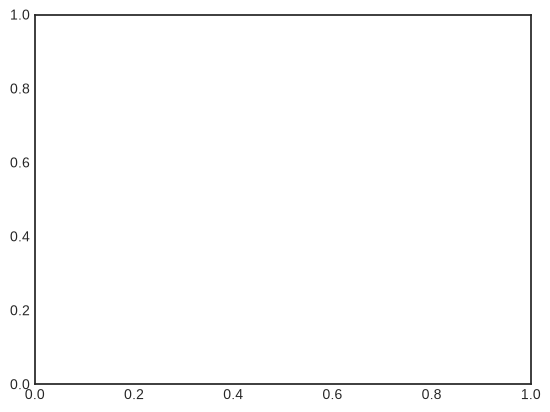

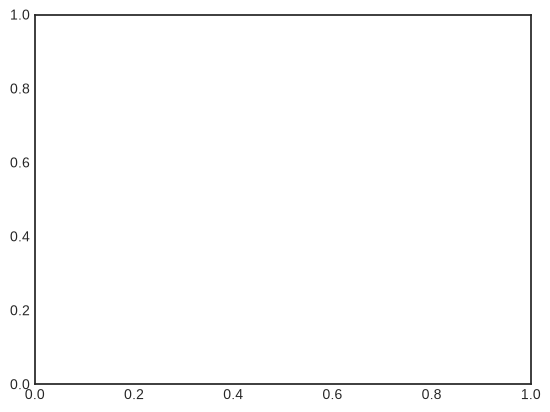

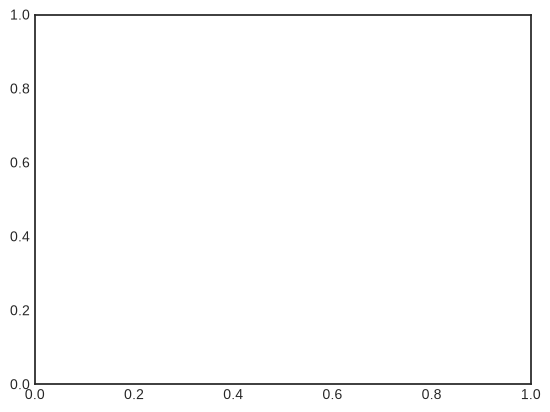

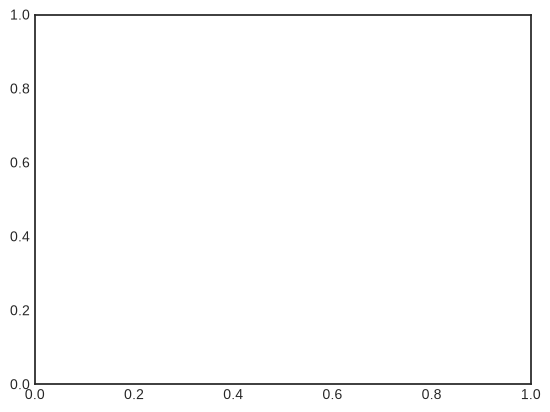

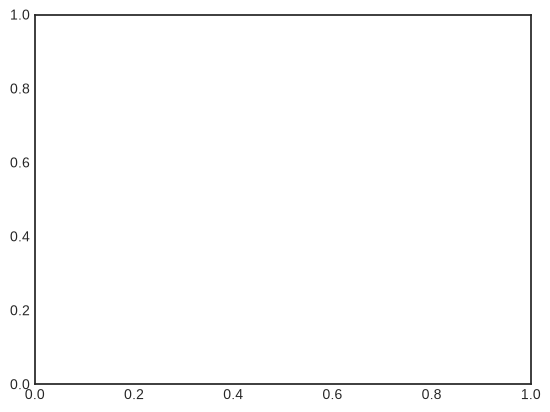

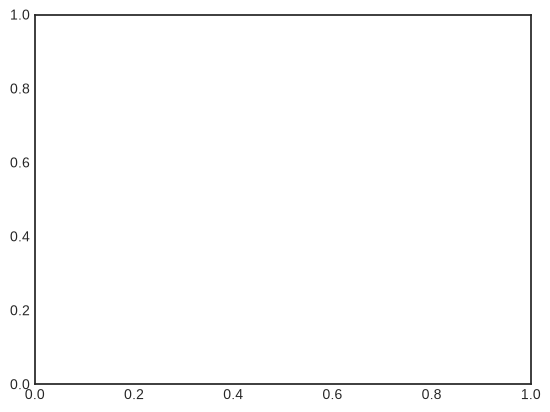

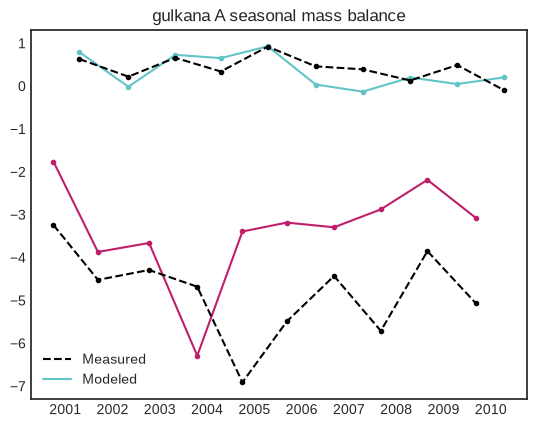

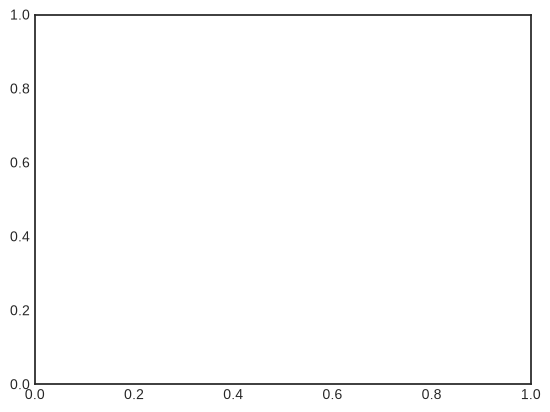

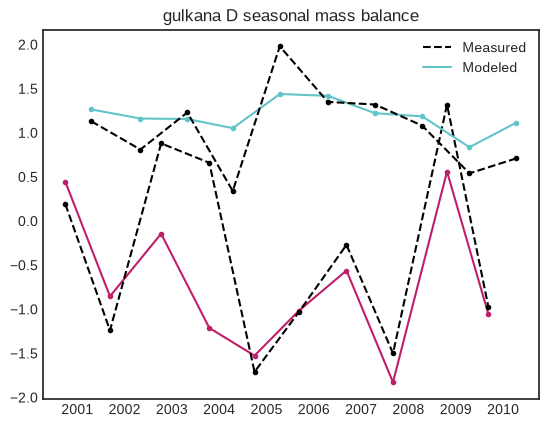

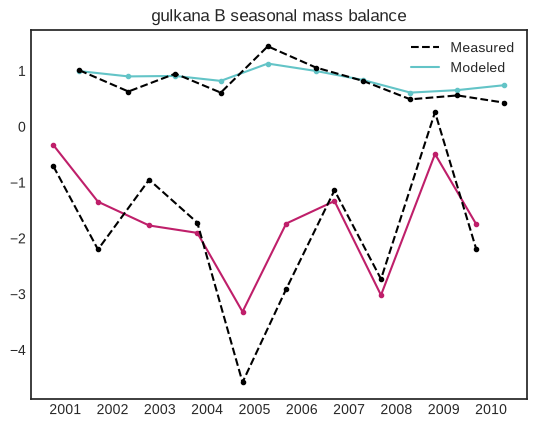

In [14]:
glacier, site = 'gulkana', 'D'
for point, rgiid, site in zip(ds_all.point, rgiids, sites):
    glacier = translate_names[rgiid]
    ds = ds_all.sel(point=point).squeeze()
    mb = MassBalance(glacier, site)
    mb.get_model_mb(ds)
    try:
        mb.plot_mb()
        plt.show()
        plt.close()
    except:
        pass

# plt.plot(ds.time, ds.total_mass)
# plt.xlim(pd.to_datetime('2007-08-01'), pd.to_datetime('2008-04-01'))
# plt.ylim(160,162)

# time = pd.date_range('2000-05-01','2010-05-01', freq='2MS')
# fig, axes = visualize_layers_fast(ds, time, ['layertemp','layergrainsize'])
# for ax in axes:
#     ax.set_xticks(pd.date_range(time[0], time[-1], freq='YS'))
#     ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y'))

(<Figure size 500x340 with 4 Axes>, array([<Axes: >, <Axes: >], dtype=object))

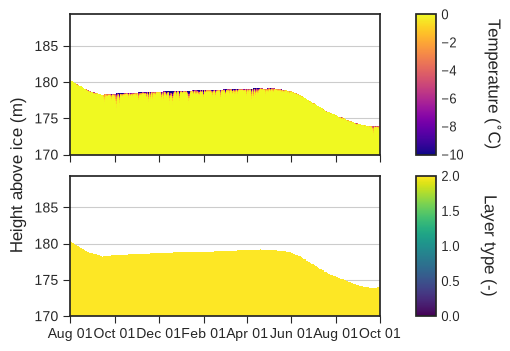

In [20]:
# ds = ds.sel(time=slice('2007-08-01','2008-10-01'))
# plt.plot(ds.time, ds.accumulation.cumsum())
# plt.plot(ds.time, ds.total_mass) # ds['layerheight'].where(ds['layertype'] < 2).sum(dim='layer'))
visualize_layers_fast(ds, pd.date_range('2007-08-01','2008-10-01'), ['layertemp','layertype'], plot_ice=True, ylim=(170, None))
# plt.xlim(pd.to_datetime('2007-08-01'), pd.to_datetime('2008-10-01'))

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 17521, layer: 50)
Coordinates:
  * time          (time) datetime64[ns] 140kB 2000-04-19T16:00:00 ... 2002-04...
  * layer         (layer) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
    point         int64 8B 0
Data variables: (12/17)
    accumulation  (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    condensation  (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    cumrefreeze   (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    deposition    (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    elev          float64 8B dask.array<chunksize=(), meta=np.ndarray>
    error         (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    ...            ...
    rainfall      (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>
    refreeze      (time) float64 140kB dask.array<chunksize=(17521,), meta=np.ndarray>

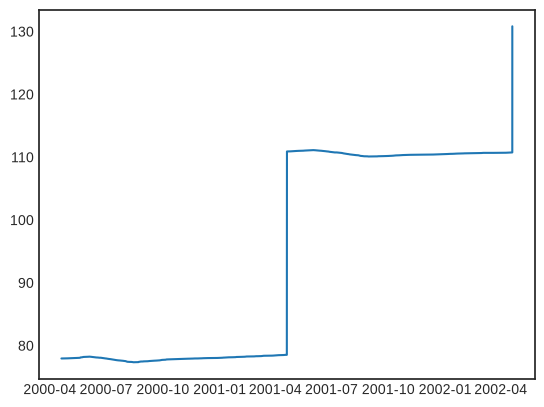

In [13]:
output_fp = '/ocean/projects/ees260009p/cwilson4/Output/recalibrate_2/'
ds_all = xr.open_zarr(output_fp + 'output.zarr')
ds_all['time'] = ds_all.time - pd.Timedelta(hours=8)

dsk = ds_all.sel(point=0)
print(dsk)
plt.plot(dsk.time, dsk.total_mass)

DatetimeIndex(['2000-04-20', '2000-04-21', '2000-04-22', '2000-04-23',
               '2000-04-24', '2000-04-25', '2000-04-26', '2000-04-27',
               '2000-04-28', '2000-04-29',
               ...
               '2021-05-22', '2021-05-23', '2021-05-24', '2021-05-25',
               '2021-05-26', '2021-05-27', '2021-05-28', '2021-05-29',
               '2021-05-30', '2021-05-31'],
              dtype='datetime64[us]', length=7590, freq=None)


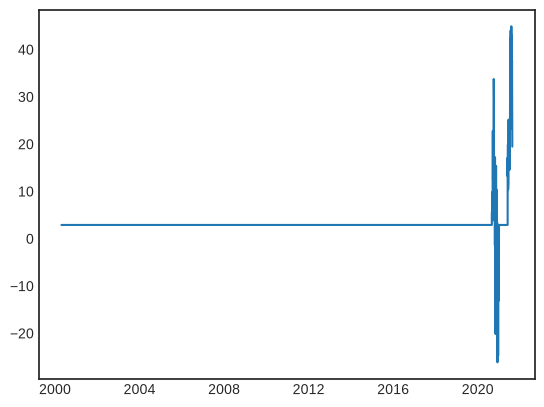

In [ ]:
glacier, site = 'gulkana', 'B'
idx = np.where((np.array(rgiids) == translate_rgi[glacier]['6']) & (np.array(sites) == site))[0]
ds = ds_all.sel(point=idx)
ds['MB'] = ds['accumulation'] + ds['refreeze'] - ds['melt']

# mb = MassBalance(glacier, site)
# mb.get_model_mb(ds)
# mb.plot_mb()
time = pd.date_range('2000-04-20','2021-08-20', freq='D')
ds = ds.sel(time=time)
# plt.plot(ds.time, ds.airtemp, label='From model output')

ds1 = xr.open_zarr('/ocean/projects/ees260009p/cwilson4/climate_data/MERRA2/reg01_fix/T2M_reg01_fix.zarr').sel(lat=63.5, lon=-145.625)
ds1['time'] = ds1.time - pd.Timedelta(hours=8, minutes=30)
ds1 = ds1.sel(time=time) - 273.15
dates_nonzero = np.where(np.abs(ds1.T2M.values - ds.airtemp.values.flatten() - 2.91970526) < 1e-3)
print(time[dates_nonzero[0]])
plt.plot(ds1.time, ds1.T2M - ds.airtemp) # , label='From MERRA-2 directly')
# plt.axvline(pd.to_datetime('2021-06-01'))
plt.show()

# ds1 = xr.open_zarr('/ocean/projects/ees260009p/cwilson4/climate_data/MERRA2/reg01/T2M_reg01.zarr').sel(lat=63.5, lon=-145.625)
# ds1['time'] = ds1.time - pd.Timedelta(hours=8, minutes=30)
# ds1 = ds1.sel(time=time) - 273.15
# plt.plot(ds1.time, ds1.T2M - ds.airtemp, label='From MERRA-2 old broken file')

# plt.legend()
# plt.show()

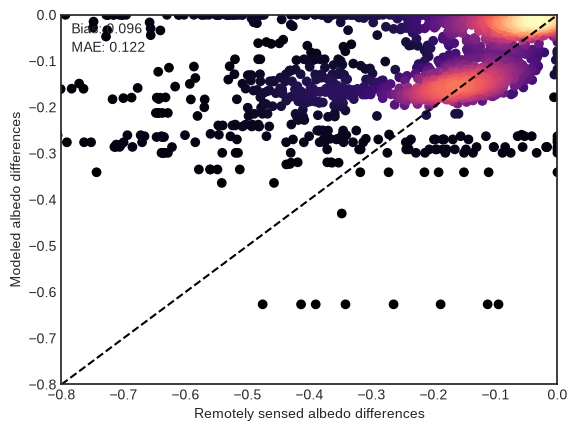

In [ ]:
deltas = True

all_mod_albedo = []
all_meas_albedo = []

for point in ds_all.point:
    rgiid = rgiids[point.values]
    site = sites[point.values]

    glacier = translate_names[rgiid]
    ab = Albedo(glacier, site)
    
    ab.get_model_albedo(ds_all.sel(point=point))
    if deltas:
        ab.get_deltas()

    for mod, meas in zip(ab.mod, ab.meas):
        all_mod_albedo.append(mod)
        all_meas_albedo.append(meas[0])

mod = np.array(all_mod_albedo).flatten()
meas = np.array(all_meas_albedo).flatten()

fig, ax = plt.subplots()
from scipy.stats import gaussian_kde
xy = np.vstack([mod, meas])
kde = gaussian_kde(xy)
z = kde(xy)

idx = z.argsort()
x, y, z = meas[idx], mod[idx], z[idx]

minn, maxx = (-0.8, 0) if deltas else (0.1, 0.9)

ax.scatter(x, y, c=z, cmap='magma')
ax.plot([minn, maxx], [minn, maxx], 'k--')

bias = np.mean(mod - meas)
MAE = np.mean(np.abs((mod - meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.90, f'MAE: {MAE:.3f}', transform=ax.transAxes)

ax.set_xlabel('Remotely sensed albedo differences')
ax.set_xlim(minn, maxx)

ax.set_ylabel('Modeled albedo differences')
ax.set_ylim(minn, maxx)

# plt.savefig('../figs/new_albedo_agreement.png', dpi=300)
plt.show()

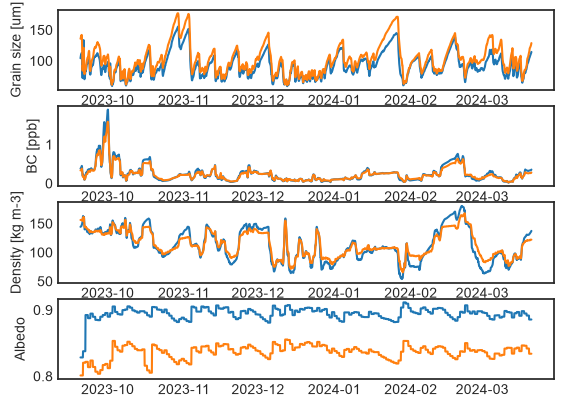

In [ ]:
glacier, site = 'gulkana','B'
gn = translate_rgi[glacier]['6']
i = 13

ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_07_07_base_0.nc')
ds1 = xr.open_zarr(f'../Output/check_2/{gn}_{i}.zarr').compute()

ds0['time'] = ds0.time + pd.Timedelta(hours=10)
time_slice = slice('2023-09-20','2024-03-20')
ds0 = ds0.sel(time=time_slice, layer=0)
ds1 = ds1.sel(time=time_slice, layer=0)
fig, axes = plt.subplots(4)

axes[0].plot(ds0.time, ds0.layergrainsize)
axes[0].plot(ds1.time, ds1.layergrainsize)
axes[0].set_ylabel('Grain size [um]')

axes[1].plot(ds0.time, ds0.layerBC)
axes[1].plot(ds1.time, ds1.layerBC)
axes[1].set_ylabel('BC [ppb]')

axes[2].plot(ds0.time, ds0.layerdensity)
axes[2].plot(ds1.time, ds1.layerdensity)
axes[2].set_ylabel('Density [kg m-3]')

axes[3].plot(ds0.time, ds0.albedo, label='Old CPU')
axes[3].plot(ds1.time, ds1.albedo, label='new GPU')
axes[3].set_ylabel('Albedo')

# axes.legend()
plt.show()

Beginning wolverine N (01.09162). . .
Beginning wolverine B (01.09162). . .
Beginning wolverine EC (01.09162). . .
Beginning kahiltna K53 (01.22193). . .
Beginning kahiltna K17b (01.22193). . .
Beginning kennicott GTL (01.15645). . .
Beginning kennicott GTH (01.15645). . .
Beginning lemon_creek B (01.01104). . .
Beginning lemon_creek C (01.01104). . .
Beginning lemon_creek D (01.01104). . .
Beginning taku NWB1 (01.01390). . .
Beginning taku TKG3 (01.01390). . .
Beginning gulkana AU (01.00570). . .
Beginning gulkana B (01.00570). . .
Beginning gulkana D (01.00570). . .


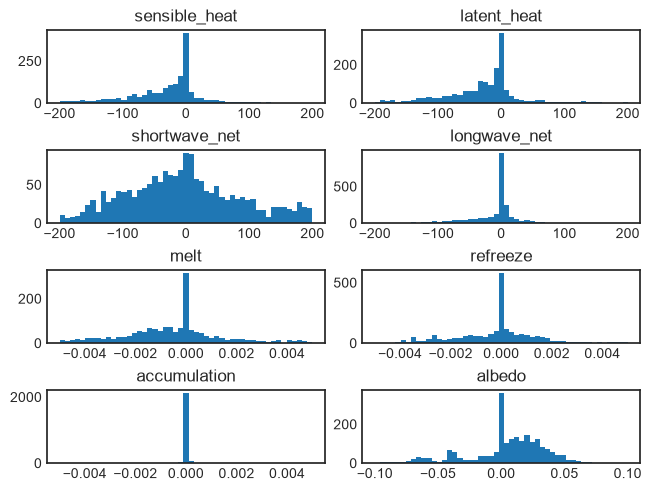

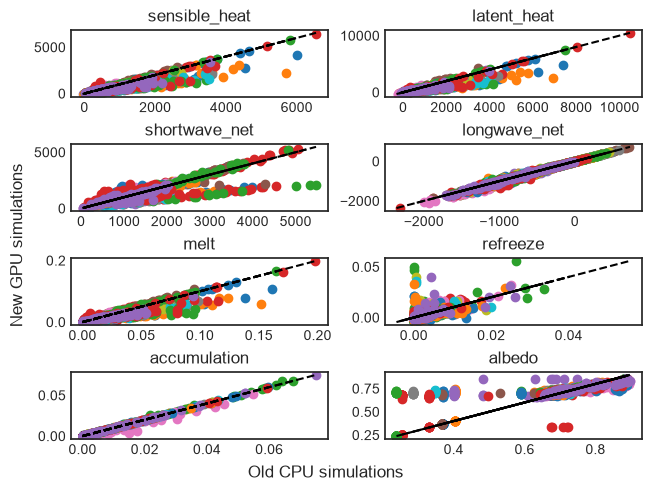

In [ ]:
plot_vars = ['sensible_heat', 'latent_heat', 'shortwave_net', 'longwave_net', 'melt','refreeze','accumulation','albedo']
resample = 'D'

fig2, axes2 = plt.subplots(4, 2)
axes2 = axes2.flatten()

all_diff = {}
for var in plot_vars:
    all_diff[var] = []

fig1, axes1 = plt.subplots(4, 2)
axes1 = axes1.flatten()

all_BC = []

i = 0
for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']

        print(f'Beginning {glacier} {site} ({gn}). . .')
        
        ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_07_07_base_0.nc')
        ds1 = xr.open_zarr(f'../Output/check_0/{gn}_{i}.zarr').compute()
        ds1['shortwave_net'] = ds1['shortwave_in'] + ds1['shortwave_ref']
        ds1['longwave_net'] = ds1['longwave_in'] + ds1['longwave_out']

        ds0['time'] = ds0.time + pd.Timedelta(hours=10)

        all_BC.append(ds1.layerBC.isel(layer=0).values)

        # common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
        common=pd.date_range('2023-04-20','2023-09-20',freq='h')
        ds0 = ds0.sel(time=common)
        ds1 = ds1.sel(time=common)

        for v, ax1 in zip(plot_vars, axes1):
            if v == 'accumulation':
                v0 = 'accum' 
            elif v == 'shortwave_in':
                v0 = 'SWin'
            elif v == 'longwave_in':
                v0 = 'LWin'
            elif v == 'shortwave_net':
                v0 = 'SWnet'
            elif v == 'longwave_net':
                v0 = 'LWnet'
            elif v.endswith('_heat'):
                v0 = v.split('_')[0]
            else:
                v0 = v

            if resample:
                if v in ['melt','accumulation', 'refreeze'] or 'shortwave' in v or 'longwave' in v or 'heat' in v:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).sum().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).sum().values
                else:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).mean().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).mean().values
            else:
                vals0 = ds0.isel(layer=0)[v0].values 
                vals1 = ds1.isel(layer=0)[v].values

            min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

            ax1.scatter(vals0, vals1, label=glacier+site)
            ax1.plot([min_value, max_value], [min_value, max_value], 'k--')
        
            diff = vals1 - vals0 
            for d in diff:
                all_diff[v].append(d)
            
            ax1.set_title(v)

        i += 1

mm =[200, 200, 200, 200, 0.005, 0.005, 0.005, 0.1]
for v, ax2, max_abs in zip(plot_vars, axes2, mm):
    # min_val = np.min(all_diff[v])
    # max_val = np.max(all_diff[v])
    # max_abs = max(abs(min_val), abs(max_val)) * 0.1
    ax2.hist(np.array(all_diff[v]), bins=np.linspace(-max_abs, max_abs, 50))
    ax2.set_title(v)

fig1.supxlabel('Old CPU simulations')
fig1.supylabel('New GPU simulations')
fig1.set_constrained_layout(constrained=True)
fig2.set_constrained_layout(constrained=True)
fig1.savefig('../figs/1to1.png')
fig2.savefig('../figs/histogram.png')
plt.show()

### Compare old shading masks (slow, individual point search) to new ones (GPU / vectorized)

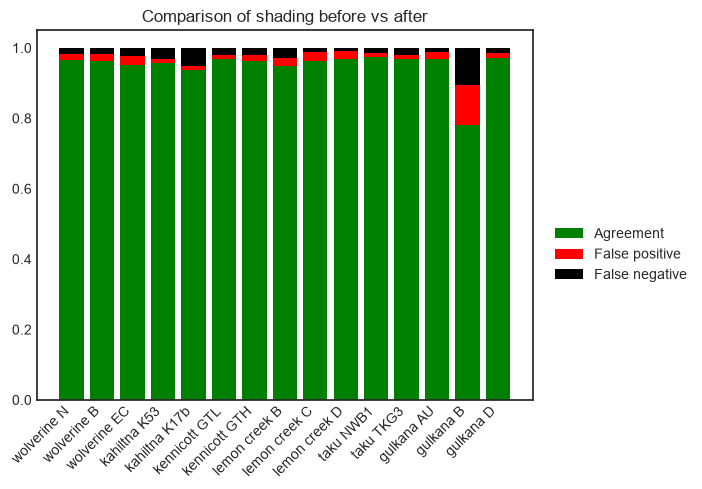

In [ ]:
shading_fp = '/Users/cvw/local/data/shading/'

# create figure
n_sites = np.sum([len(s) for _, s in site_dict.items()])
fig, ax = plt.subplots()
sites = []
i = 0
for glacier in site_dict:
    glacier_id = translate_rgi[glacier]['6']

    # load the shading file
    file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find shadow file: {file_path}")

    ds = xr.open_zarr(file_path).compute()

    # apply coordinate corrections as needed
    local_times = ds.time.values - np.timedelta64(8, "h")
    ds = ds.assign_coords(time=local_times)
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

    # read in the site constants file for this glacier
    df = pd.read_csv(f'data/by_glacier/{glacier}/site_constants.csv', index_col='site')

    for site in site_dict[glacier]:
        # grab lat/lon for this site and convert it to x/y
        point_to_grab = (df.loc[site, 'lat'], df.loc[site, 'lon'])
        transformer = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
        x_pts, y_pts = transformer.transform(point_to_grab[1], point_to_grab[0])

        # get xr DataArrays for the slicing variables
        target_x = xr.DataArray([x_pts], dims='points')
        target_y = xr.DataArray([y_pts], dims='points')

        new_ds = ds.sel(y=target_y, x=target_x, method='nearest').shadow_mask

        # load the old shadow mask
        old_mask = pd.read_csv(f'data/by_glacier/{glacier}/shade/{glacier}{site}_shade.csv', parse_dates=True, index_col=0)
        old_mask['doy'] = old_mask.index.day_of_year
        old_mask['hour'] = old_mask.index.hour

        # load the new shadow mask into a dataframe identical to old_mask
        new_mask = new_ds.to_dataframe(name='shadow_mask').reset_index()
        new_mask['doy'] = pd.DatetimeIndex(new_mask['time']).day_of_year
        new_mask['hour'] = pd.DatetimeIndex(new_mask['time']).hour

        # merge on doy/hour
        comparison = old_mask.merge(new_mask[['doy', 'hour', 'shadow_mask']], 
                                    on=['doy', 'hour'], 
                                    suffixes=('_old', '_new'))

        # calculate error metrics
        old = ~comparison['shaded']
        new = comparison['shadow_mask']
        tp = (old & new).sum()        # both say shadowed
        tn = (~old & ~new).sum()      # both say lit
        fp = (~old & new).sum()       # old says lit, new says shadowed
        fn = (old & ~new).sum()       # old says shadowed, new says lit
        n = len(old)

        # plot stacked bar chart of errors
        ax.bar(i, (tp+tn)/n, color='green')
        ax.bar(i, fp/n, bottom=(tp+tn)/n, color='red')
        ax.bar(i, fn/n, bottom=(tp+tn)/n + fp/n, color='k')
        i+= 1
        sites.append(glacier.replace('_',' ')+' '+site)
ax.bar(0, np.nan, color='green', label='Agreement')
ax.bar(0, np.nan, color='red', label='False positive')
ax.bar(0, np.nan, color='k', label='False negative')
ax.legend(bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(n_sites))
ax.set_xticklabels(sites, rotation=45, ha='right')
ax.set_title('Comparison of shading before vs after')
plt.savefig('../shading_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot the actual shadow mask for a given day of year / hours of day

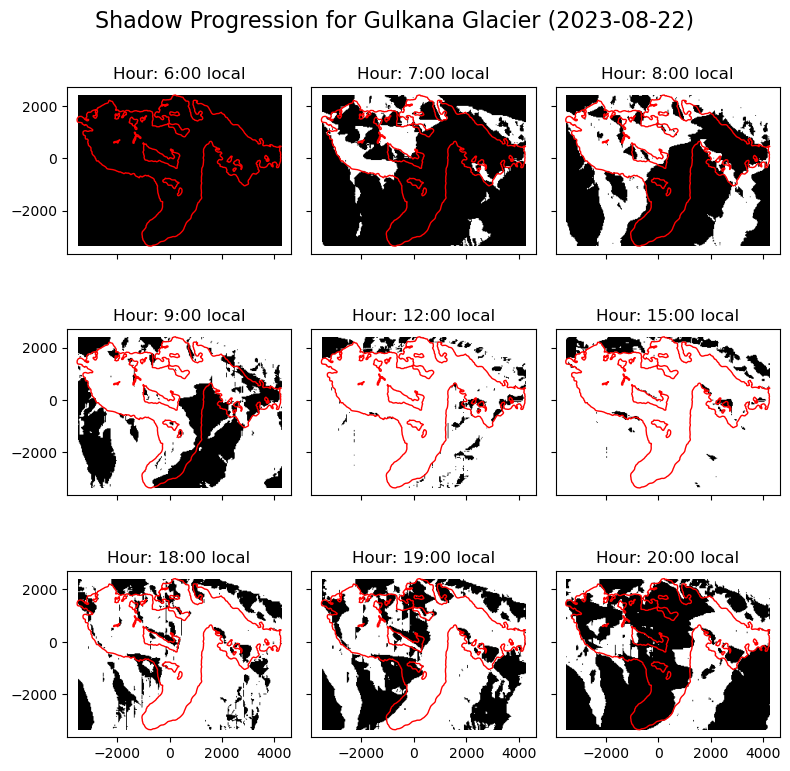

In [ ]:
shading_fp = '/home/claire/Local/data/shading/'

glacier = 'gulkana'
glacier_id = translate_rgi[glacier]['6']
date = '2023-08-22'
target_local_hours = [6, 7, 8, 9, 12, 15, 18, 19, 20]

# load the shading file
file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find shadow file: {file_path}")

ds = xr.open_dataset(file_path)

# apply coordinate corrections as needed
local_times = ds.time.values - np.timedelta64(8, "h")
ds = ds.assign_coords(time=local_times)
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

# select the day specified
date_doy = pd.to_datetime(date).day_of_year
glacier_day = ds.sel(time=ds.time.dt.dayofyear == date_doy)

# initialize plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

# load the RGI geodataframe for the shapefile
gdf = gpd.read_file('/home/claire/Local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
gdf = gdf.loc[gdf['RGIId'] == 'RGI60-'+glacier_id]
gdf = gdf.to_crs(ds.rio.crs)

# loop through hours
for i, hour in enumerate(target_local_hours):
    ax = axes[i]

    # select the specific hour slice
    hourly_data = glacier_day.sel(time=glacier_day.time.dt.hour == hour)

    # pull out 2D spatial grid
    shadow_grid = hourly_data['shadow_mask'].values.squeeze()

    # Plot the binary shadow map
    # sun = white, shade = black
    im = ax.imshow(
        shadow_grid,
        cmap="gray",
        extent=[
            ds.x.min().item(),
            ds.x.max().item(),
            ds.y.min().item(),
            ds.y.max().item(),
        ],
        origin="upper",
    )

    ax.set_title(f"Hour: {hour}:00 local")

    # plot the shapefile
    gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=1)

fig.suptitle(
    f"Shadow Progression for {glacier.replace('_',' ').capitalize()} Glacier ({date})",
    fontsize=16, y=0.98
)
plt.tight_layout()
plt.savefig('../shadow_map.png', bbox_inches='tight', dpi=300)
plt.show()

ds.close()

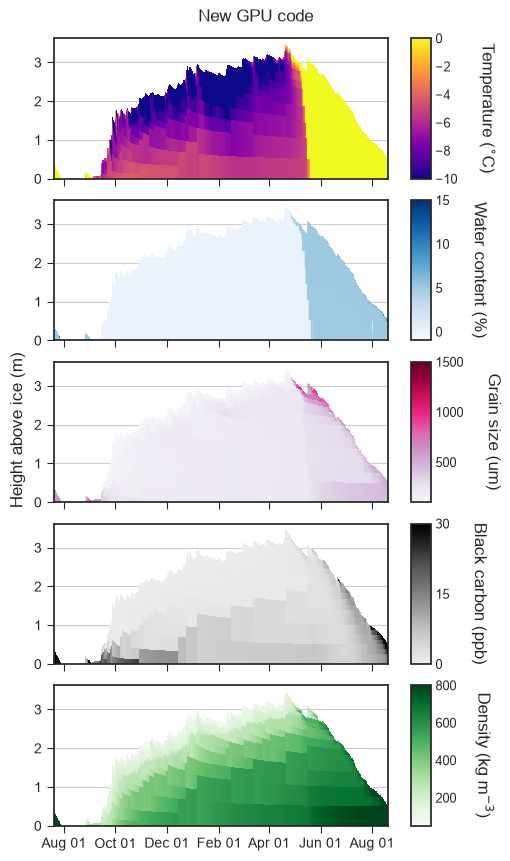

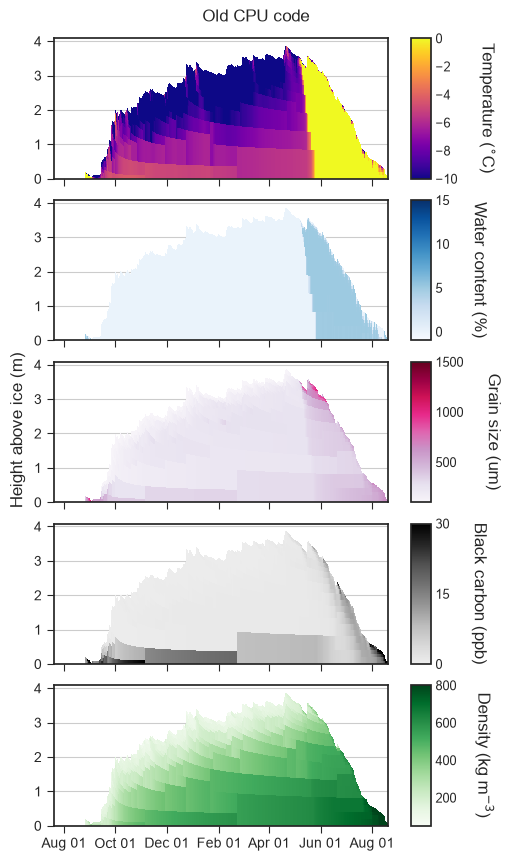

In [ ]:
ds1 = xr.open_zarr(f'../Output/check_7/{gn}_{i}.zarr').compute()
fig, ax = visualize_layers(ds1, pd.date_range('2004-07-20','2005-08-20'), ['layertemp', 'layerwater','layergrainsize','layerBC','layerdensity'])
fig.suptitle('New GPU code')
plt.show() 

ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_07_07_base_0.nc')
fig, ax = visualize_layers(ds0, pd.date_range('2004-07-20','2005-08-20'), ['layertemp','layerwater', 'layergrainsize','layerBC','layerdensity'])
fig.suptitle('Old CPU code')
plt.show() 

<xarray.DataArray 'PHIS' ()> Size: 8B
array(279)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    long_name:       surface geopotential height
    units:           m+2 s-2
    fmissing_value:  1e+15
    standard_name:   surface geopotential height
    vmax:            1e+15
    vmin:            -1e+15
    valid_range:     [-1.e+15  1.e+15]


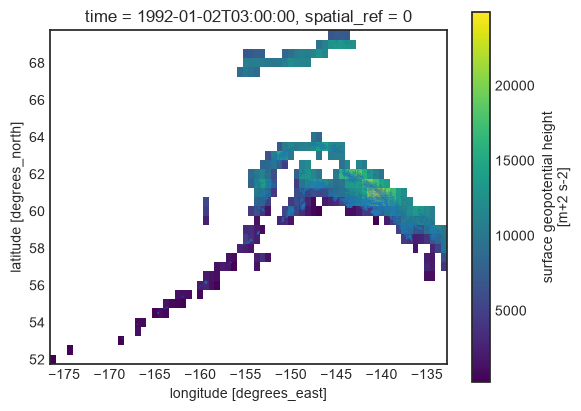

In [ ]:
ds = xr.open_dataset('../climate_data/MERRA2/MERRA2_constants.nc')
ds = ds.sel(lat=slice(50, 72), lon=slice(-180, -133))
ds = ds.rio.write_crs("EPSG:4326")
ds = ds.rename({'lat':'y', 'lon':'x'})

import geopandas as gpd
rgi = gpd.read_file('/Users/cvw/local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')

if rgi.crs != ds.rio.crs:
    rgi = rgi.to_crs(ds.rio.crs)

clipped_ds = ds.rio.clip(rgi.geometry, rgi.crs, drop=True, all_touched=True)

fig, ax = plt.subplots()

clipped_ds['PHIS'].plot(ax=ax)
rgi.plot(ax=ax)

print(clipped_ds['PHIS'].count())